In [25]:
import pandas as pd
import numpy as nm
import seaborn as sns
import matplotlib.pyplot  as plt

In [4]:
startup_data = pd.read_csv('C:/Users/harir/Downloads/Multi Linear Regression/50_startups.csv') 
print(startup_data)

    R&D Spend  Administration  Marketing Spend       State     Profit
0   165349.20       136897.80        471784.10    New York  192261.83
1   162597.70       151377.59        443898.53  California  191792.06
2   153441.51       101145.55        407934.54     Florida  191050.39
3   144372.41       118671.85        383199.62    New York  182901.99
4   142107.34        91391.77        366168.42     Florida  166187.94
5   131876.90        99814.71        362861.36    New York  156991.12
6   134615.46       147198.87        127716.82  California  156122.51
7   130298.13       145530.06        323876.68     Florida  155752.60
8   120542.52       148718.95        311613.29    New York  152211.77
9   123334.88       108679.17        304981.62  California  149759.96
10  101913.08       110594.11        229160.95     Florida  146121.95
11  100671.96        91790.61        249744.55  California  144259.40
12   93863.75       127320.38        249839.44     Florida  141585.52
13   91992.39       

In [5]:
startup_data.shape

(50, 5)

In [6]:
startup_data.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')

In [7]:
startup_data.dtypes

R&D Spend          float64
Administration     float64
Marketing Spend    float64
State               object
Profit             float64
dtype: object

In [8]:
startup_data.isna().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [9]:
startup_data['State'] = startup_data['State'].str.strip()
state_mapping = {'New York':0,'California':1,'Florida':2}
startup_data['State'] = startup_data['State'].map(state_mapping)
startup_data['State']
startup_data.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,0,192261.83
1,162597.70,151377.59,443898.53,1,191792.06
2,153441.51,101145.55,407934.54,2,191050.39
3,144372.41,118671.85,383199.62,0,182901.99
4,142107.34,91391.77,366168.42,2,166187.94


In [11]:
X = startup_data.iloc[:,0:4]
y = startup_data.iloc[:,-1]

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)
X_train.shape,y_train.shape

((40, 4), (40,))

In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
model = LinearRegression()
model.fit(X_train,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
model.coef_

array([ 8.00595547e-01, -2.22054421e-02,  2.12954367e-02,  2.54057678e+02])

In [16]:
model.intercept_

np.float64(50418.186200174925)

In [17]:
pred_profits = model.predict(X_test)
pred_profits

array([ 99549.12175885,  70614.88216196, 112888.29341387,  89011.51233164,
        47665.0292441 , 128566.43644159,  99931.61995826, 186938.84511468,
       171527.33704831,  89744.87757976])

In [18]:
from sklearn.metrics import r2_score

In [21]:
accurracy = r2_score(y_test,pred_profits)*100
print("Accurracy of the multi linear regression-",accurracy)

Accurracy of the multi linear regression- 97.88771990935037


In [22]:
pd.DataFrame({"Actual_profits":y_test,"Predicted_profits":pred_profits})

,Actual_profits,Predicted_profits
32,97427.84,99549.121759
42,71498.49,70614.882162
24,108552.04,112888.293414
37,89949.14,89011.512332
47,42559.73,47665.029244
12,141585.52,128566.436442
30,99937.59,99931.619958
1,191792.06,186938.845115
3,182901.99,171527.337048
35,96479.51,89744.877580


In [23]:
Error_percentage = 100 - accurracy
Error_percentage

2.1122800906496337

<Axes: xlabel='R&D Spend'>

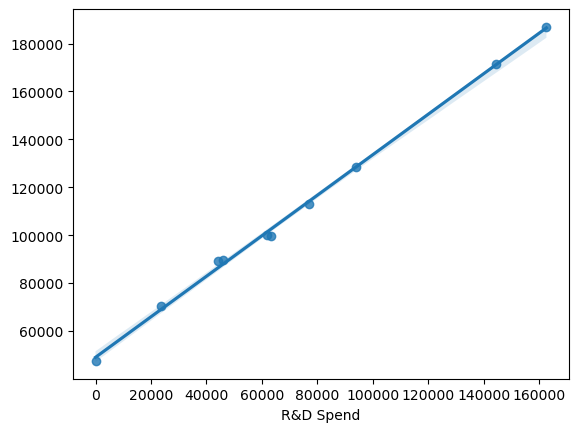

In [28]:
sns.regplot(x= X_test['R&D Spend'],y = pred_profits)

<Axes: xlabel='Administration'>

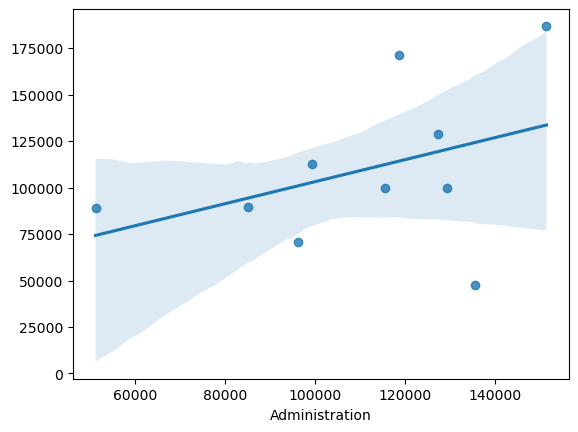

In [29]:
sns.regplot(x= X_test['Administration'],y = pred_profits)

<Axes: xlabel='Marketing Spend'>

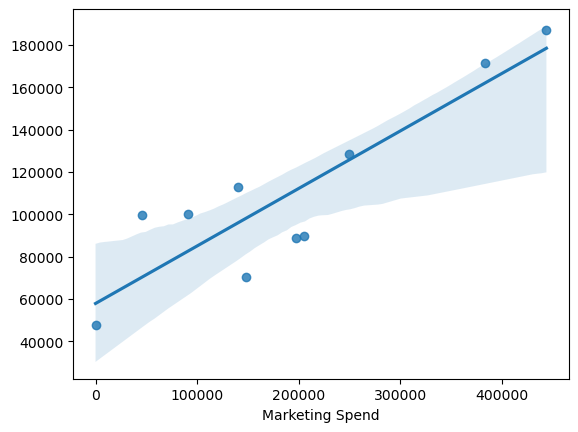

In [30]:
sns.regplot(x= X_test['Marketing Spend'],y = pred_profits)

<Axes: xlabel='State'>

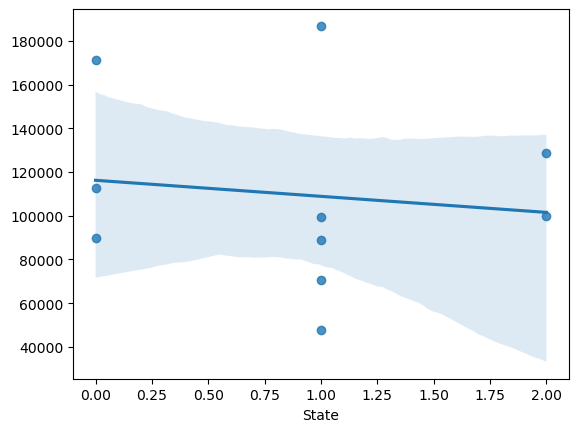

In [33]:
sns.regplot(x= X_test['State'],y = pred_profits)

In [37]:
import joblib
joblib.dump(model,'profitpredictionmodel.joblib')

['profitpredictionmodel.joblib']